# Acoustic Detection Data Analysis

**Name:** Jacqueline Wu  
**Date:** April 3, 2026  

## Metadata

In this notebook, I analyze a bird acoustic detection dataset, collected across three preserves (Hoh, Clearwater, and Ellsworth), filtered by Gio's calibration thresholds. The fields in the dataset are: detected species, detection confidence, date, hour, and locations across different sites, plots, and ARUs.

I will analyze this dataset in the following ways:

*   Species perspective: which species are detected most often and how detection patterns differ among species.

*   Temporal perspective: changes across dates and within a day to describe temporal trends and species activity patterns.

*  Community perspective: compare species activity curves and look at possible temporal overlap among co-occurring species.

*  Spatial perspective: compare detections across sites, plots, and ARUs.

## Goal of This Notebook
The goal of this notebook is to describe bird detection patterns across species, time, and space.

## Data Loading and Initial Inspection

In this section, I load the three uploaded files and inspect their structure. This step is necessary to confirm that the datasets were imported correctly, identify the available variables, and determine how the three tables may be linked for later analysis.

In [ ]:
import pandas as pd

# Load the main detections dataset
detections_path = "/content/detections_kept_gte_threshold.csv"
detections = pd.read_csv(detections_path)

# Load the habitat / site metadata sheet
metadata_path = "/content/Biodiversity Data Processing_Master Sheet.xlsx"
metadata_df = pd.read_excel(metadata_path)

# Preview the first few rows of each dataset
print("Detections dataset preview:")
display(detections.head())

print("Metadata sheet preview:")
display(metadata_df.head())

# Check dataset dimensions
print("Detections dataset shape:", detections.shape)
print("Metadata dataset shape:", metadata_df.shape)

# Check column names
print("Detections columns:")
print(detections.columns.tolist())

print("Metadata columns:")
print(metadata_df.columns.tolist())

Detections dataset preview:


,site,plot,aru,date,hour,detection_common_name,start_s,end_s,detection_confidence,source,...,auc_pr,auc_roc,calibration_threshold,precision,recall,method,calibration_threshold_raw,threshold_is_inf,calibration_threshold_num,calibration_status
0,Ellsworth,1.0,984,2025-05-08,0,common raven,345,348,0.9550,2MM09984_20250508_000000.BirdNET.results.csv,...,0.981,0.995,0.743,1.0,0.811,probabilistic,0.743,False,0.743,numeric_threshold
1,Ellsworth,1.0,984,2025-05-08,1,common raven,240,243,0.8489,2MM09984_20250508_010000.BirdNET.results.csv,...,0.981,0.995,0.743,1.0,0.811,probabilistic,0.743,False,0.743,numeric_threshold
2,Ellsworth,1.0,984,2025-05-08,6,white-crowned sparrow,156,159,0.8955,2MM09984_20250508_060000.BirdNET.results.csv,...,0.990,0.998,0.729,1.0,0.941,probabilistic,0.729,False,0.729,numeric_threshold
3,Ellsworth,1.0,984,2025-05-08,6,white-crowned sparrow,189,192,0.9640,2MM09984_20250508_060000.BirdNET.results.csv,...,0.990,0.998,0.729,1.0,0.941,probabilistic,0.729,False,0.729,numeric_threshold
4,Ellsworth,1.0,984,2025-05-08,6,white-crowned sparrow,198,201,0.9573,2MM09984_20250508_060000.BirdNET.results.csv,...,0.990,0.998,0.729,1.0,0.941,probabilistic,0.729,False,0.729,numeric_threshold


Metadata sheet preview:


,Property,UTM E,UTM N,Plot ID,ARU Number,Camera,Camera SD Card #,Approximate Travel Time (mins),Route Description,Dominant Ecosystem Type,Dominant Tree Species,Dominant Understory Plant(s),Habitat Description
0,Ellsworth,430177.58,5134085.48,1,984,Yes,6,5,"Go up the hill, follow the flags, camera is on...",Clear_cut,"Western_Hemlock,Sitka_Spruce","Salmon berry, grasses, salal, ferns","Camera D, clear cut, slight west aspect just b..."
1,Ellsworth,429035.02,5135254.99,9,608,Yes,12,5,Camera G,Forest_Dense,"Western_Hemlock,Douglas_Fir","Sword fern, salmon berry","Open understory, dense canopy, trail runs east..."
2,Ellsworth,432654.54,5136449.37,31,541,Yes,9,10,Over the ridge from the road following blue an...,Forest_Dense,"Western_Red_Cedar,Douglas_Fir,Other",Salal,"Thick undergrowth in open forest , west facing..."
3,Ellsworth,428527.74,5136993.96,33,596,Yes,1,12,Bramble downhill walk crossing through wetland,Forest_Dense,"Western_Red_Cedar,Western_Hemlock",Salal,Camera1 wetland muck and plants in the bottom ...
4,Ellsworth,432538.45,5137588.99,50,531,Yes,4,10,Down the hill. Small gully. Lovely spot.,Forest_Open,"Douglas_Fir,Western_Hemlock","Ferns, wood sorel",Roughly ten yr old thinning. Camera K is facin...


Detections dataset shape: (1640134, 24)
Metadata dataset shape: (35, 13)
Detections columns:
['site', 'plot', 'aru', 'date', 'hour', 'detection_common_name', 'start_s', 'end_s', 'detection_confidence', 'source', 'scientific_name', 'model', 'n_tp', 'n_tn', 'auc_pr', 'auc_roc', 'calibration_threshold', 'precision', 'recall', 'method', 'calibration_threshold_raw', 'threshold_is_inf', 'calibration_threshold_num', 'calibration_status']
Metadata columns:
['Property', 'UTM E', 'UTM N', 'Plot ID', 'ARU Number', 'Camera', 'Camera SD Card #', 'Approximate Travel Time  (mins) ', 'Route Description', 'Dominant Ecosystem Type', 'Dominant Tree Species', 'Dominant Understory Plant(s)', 'Habitat Description']


## Standardize keys and merge datasets

I first standardize the shared identifiers between the detections dataset and the metadata sheet. This step is necessary to ensure that each detection record is matched to the correct site, plot, and ARU-level metadata.

In [ ]:
# Select only the columns needed for merging and habitat interpretation
metadata_clean = metadata_df[[
    "Property",
    "Plot ID",
    "ARU Number",
    "Dominant Ecosystem Type",
    "Dominant Tree Species",
    "Dominant Understory Plant(s)",
    "Habitat Description"
]].copy()

# Standardize key columns in detections
detections["site_std"] = detections["site"].astype(str).str.strip().str.lower()
detections["plot_std"] = pd.to_numeric(detections["plot"], errors="coerce")
detections["aru_std"] = pd.to_numeric(detections["aru"], errors="coerce")

# Standardize key columns in metadata
metadata_clean["site_std"] = metadata_clean["Property"].astype(str).str.strip().str.lower()
metadata_clean["plot_std"] = pd.to_numeric(metadata_clean["Plot ID"], errors="coerce")
metadata_clean["aru_std"] = pd.to_numeric(metadata_clean["ARU Number"], errors="coerce")

# Check for missing values in merge keys
print("Missing values in detections merge keys:")
print(detections[["site_std", "plot_std", "aru_std"]].isna().sum())

print("\nMissing values in metadata merge keys:")
print(metadata_clean[["site_std", "plot_std", "aru_std"]].isna().sum())

# Test whether all metadata key combinations are unique
metadata_key_duplicates = metadata_clean.duplicated(
    subset=["site_std", "plot_std", "aru_std"]
).sum()

print(f"\nNumber of duplicated key rows in metadata: {metadata_key_duplicates}")

# Merge detections with metadata
merged_df = detections.merge(
    metadata_clean,
    on=["site_std", "plot_std", "aru_std"],
    how="left"
)

# Check merge success
print("\nMerged dataset shape:", merged_df.shape)

matched_rows = merged_df["Property"].notna().sum()
unmatched_rows = merged_df["Property"].isna().sum()

print(f"Matched detection rows: {matched_rows}")
print(f"Unmatched detection rows: {unmatched_rows}")
print(f"Match rate: {matched_rows / len(merged_df):.2%}")

# Preview unmatched rows if any
unmatched_preview = merged_df[merged_df["Property"].isna()][
    ["site", "plot", "aru", "source"]
].drop_duplicates()

print("\nPreview of unmatched key combinations:")
display(unmatched_preview.head(20))

Missing values in detections merge keys:
site_std        0
plot_std    43071
aru_std         0
dtype: int64

Missing values in metadata merge keys:
site_std    0
plot_std    0
aru_std     0
dtype: int64

Number of duplicated key rows in metadata: 0

Merged dataset shape: (1640134, 34)
Matched detection rows: 875106
Unmatched detection rows: 765028
Match rate: 53.36%

Preview of unmatched key combinations:


,site,plot,aru,source
28426,Ellsworth,13.0,388,2MM12388_20250508_020000.BirdNET.results.csv
28427,Ellsworth,13.0,388,2MM12388_20250508_050000.BirdNET.results.csv
28463,Ellsworth,13.0,388,2MM12388_20250508_060000.BirdNET.results.csv
28488,Ellsworth,13.0,388,2MM12388_20250508_070000.BirdNET.results.csv
28596,Ellsworth,13.0,388,2MM12388_20250508_080000.BirdNET.results.csv
28626,Ellsworth,13.0,388,2MM12388_20250508_090000.BirdNET.results.csv
28679,Ellsworth,13.0,388,2MM12388_20250508_100000.BirdNET.results.csv
28722,Ellsworth,13.0,388,2MM12388_20250508_110000.BirdNET.results.csv
28766,Ellsworth,13.0,388,2MM12388_20250508_120000.BirdNET.results.csv
28790,Ellsworth,13.0,388,2MM12388_20250508_150000.BirdNET.results.csv


## Problem and Scope of the current analysis

To establish a working analysis pipeline, the main analyses in this notebook focus on questions that can be answered directly from the threshold-filtered detections dataset. Habitat-related analyses require additional metadata matching.

> Because metadata are currently incomplete for a substantial portion of detections, habitat-based questions will be treated separately and restricted to the subset of records with available metadata. (mention it during Moday's meeting)



## Brief overview of the detections dataset

This includes total detections across sites, the most frequently detected species overall, and broad temporal patterns by hour and date. These summaries provide general context for the rest of the notebook.

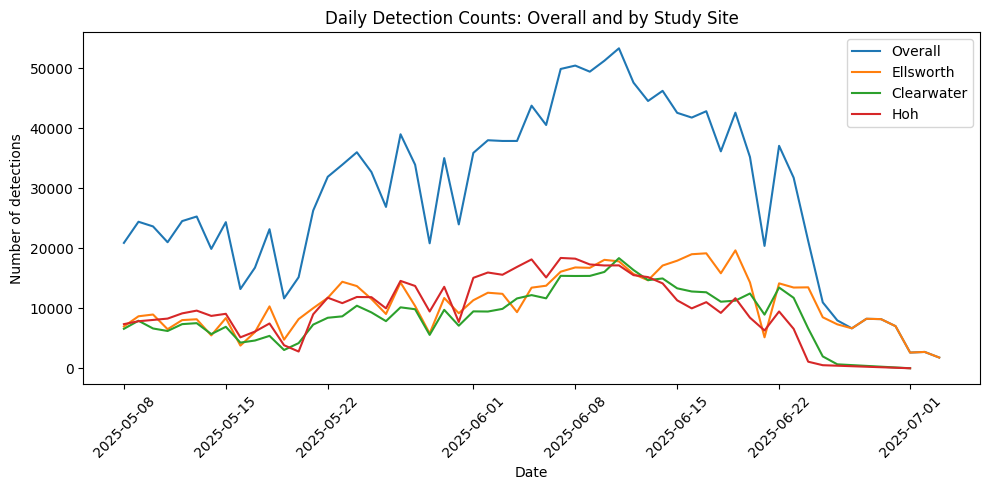

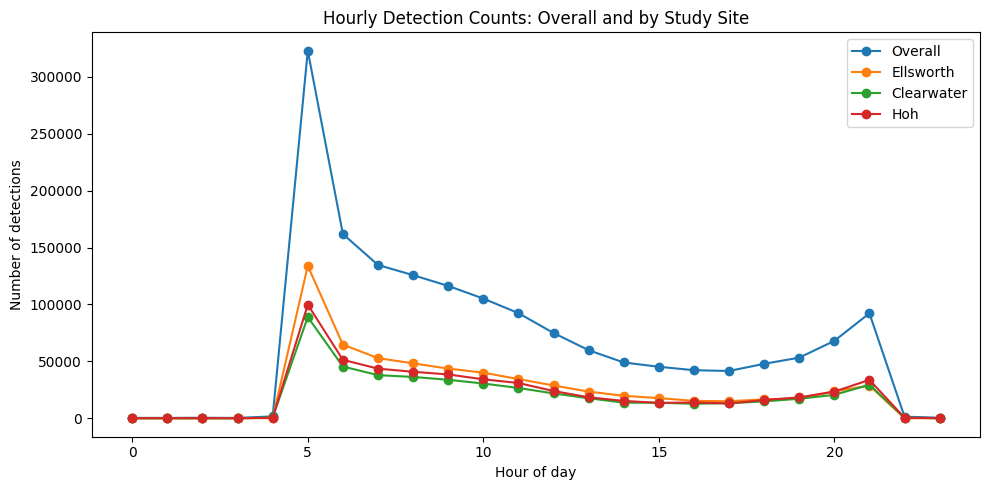

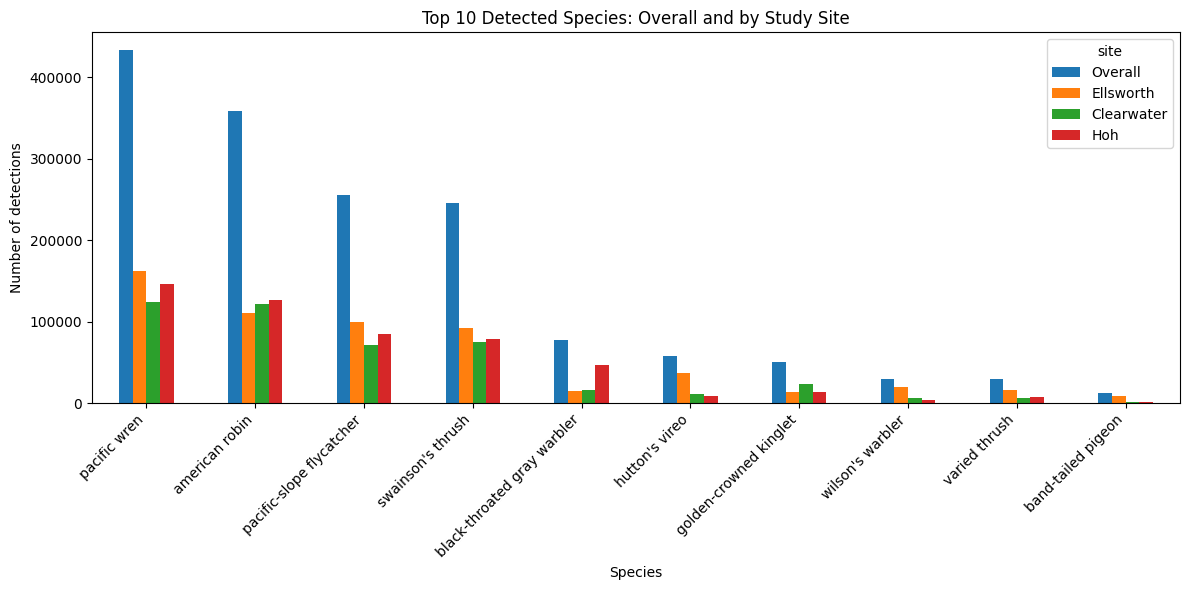

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Basic preparation
# -----------------------------

# Make a copy to avoid changing the original dataframe
df = detections.copy()

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Standardize site names if needed
df["site"] = df["site"].astype(str).str.strip()

# Define site order
site_order = ["Ellsworth", "Clearwater", "Hoh"]

# -----------------------------
# 1. Detections by date
# -----------------------------

# Overall daily detections
daily_total = (
    df.groupby("date")
    .size()
    .reset_index(name="detections")
)
daily_total["group"] = "Overall"

# Site-level daily detections
daily_site = (
    df.groupby(["date", "site"])
    .size()
    .reset_index(name="detections")
    .rename(columns={"site": "group"})
)

# Combine overall and site-level data
daily_plot_df = pd.concat([daily_total, daily_site], ignore_index=True)

# Plot
plt.figure(figsize=(10, 5))
for group in ["Overall"] + site_order:
    subset = daily_plot_df[daily_plot_df["group"] == group]
    plt.plot(subset["date"], subset["detections"], label=group)

plt.title("Daily Detection Counts: Overall and by Study Site")
plt.xlabel("Date")
plt.ylabel("Number of detections")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Detections by hour
# -----------------------------

# Overall hourly detections
hourly_total = (
    df.groupby("hour")
    .size()
    .reset_index(name="detections")
)
hourly_total["group"] = "Overall"

# Site-level hourly detections
hourly_site = (
    df.groupby(["hour", "site"])
    .size()
    .reset_index(name="detections")
    .rename(columns={"site": "group"})
)

# Combine overall and site-level data
hourly_plot_df = pd.concat([hourly_total, hourly_site], ignore_index=True)

# Plot
plt.figure(figsize=(10, 5))
for group in ["Overall"] + site_order:
    subset = hourly_plot_df[hourly_plot_df["group"] == group]
    plt.plot(subset["hour"], subset["detections"], marker="o", label=group)

plt.title("Hourly Detection Counts: Overall and by Study Site")
plt.xlabel("Hour of day")
plt.ylabel("Number of detections")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Top detected species overall with site comparison
# -----------------------------

# Select top 10 species based on total detections across the full dataset
top_species = (
    df["detection_common_name"]
    .value_counts()
    .head(10)
    .index
)

species_counts = (
    df[df["detection_common_name"].isin(top_species)]
    .groupby(["detection_common_name", "site"])
    .size()
    .reset_index(name="detections")
)

# Add overall counts
species_total = (
    df[df["detection_common_name"].isin(top_species)]
    .groupby("detection_common_name")
    .size()
    .reset_index(name="detections")
)
species_total["site"] = "Overall"

species_plot_df = pd.concat([species_total, species_counts], ignore_index=True)

# Set species order based on overall counts
species_order = species_total.sort_values("detections", ascending=False)["detection_common_name"]

# Pivot for grouped bar chart
species_pivot = (
    species_plot_df.pivot(index="detection_common_name", columns="site", values="detections")
    .reindex(species_order)
    .fillna(0)
)

# Keep a consistent column order
species_pivot = species_pivot.reindex(columns=["Overall"] + site_order)

# Plot
species_pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Top 10 Detected Species: Overall and by Study Site")
plt.xlabel("Species")
plt.ylabel("Number of detections")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count detections for each species
species_counts = (
    detections["detection_common_name"]
    .value_counts()
    .reset_index()
)

species_counts.columns = ["species", "n_detections"]

# Display the full summary table
print("Species detection count summary:")
display(species_counts)

# Show the least-detected species
print("Least-detected species:")
display(species_counts.sort_values("n_detections", ascending=True).head(15))

# Show the most-detected species
print("Most-detected species:")
display(species_counts.head(15))

# Check how many species would remain under different thresholds
thresholds = [10, 25, 50, 100, 200, 500, 1000]

threshold_summary = pd.DataFrame({
    "min_detections": thresholds,
    "n_species_retained": [
        (species_counts["n_detections"] >= t).sum() for t in thresholds
    ]
})

print("Number of species retained under different minimum detection thresholds:")
display(threshold_summary)

Species detection count summary:


,species,n_detections
0,pacific wren,433355
1,american robin,358479
2,pacific-slope flycatcher,255010
3,swainson's thrush,245133
4,black-throated gray warbler,77518
5,hutton's vireo,58234
6,golden-crowned kinglet,50406
7,wilson's warbler,30054
8,varied thrush,29776
9,band-tailed pigeon,11920


Least-detected species:


,species,n_detections
50,sharp-shinned hawk,2
49,canada jay,15
48,pine siskin,19
47,red-tailed hawk,19
46,american goldfinch,21
45,tree swallow,28
44,american crow,33
43,orange-crowned warbler,43
42,bald eagle,54
41,marbled murrelet,63


Most-detected species:


,species,n_detections
0,pacific wren,433355
1,american robin,358479
2,pacific-slope flycatcher,255010
3,swainson's thrush,245133
4,black-throated gray warbler,77518
5,hutton's vireo,58234
6,golden-crowned kinglet,50406
7,wilson's warbler,30054
8,varied thrush,29776
9,band-tailed pigeon,11920


Number of species retained under different minimum detection thresholds:


,min_detections,n_species_retained
0,10,50
1,25,46
2,50,43
3,100,39
4,200,37
5,500,34
6,1000,28


## Species Activity Curves and Temporal Overlap

This section examines within-day detection patterns for all species with at least 500 detections in the dataset. Restricting the analysis to species with sufficient detections helps reduce noise in hourly activity estimates and provides a more stable basis for temporal overlap comparisons.

Pairwise temporal overlap among selected species:


,species_1,species_2,temporal_overlap
128,black-throated gray warbler,wilson's warbler,0.934931
227,wilson's warbler,red crossbill,0.913541
126,black-throated gray warbler,hutton's vireo,0.911178
228,wilson's warbler,townsend's warbler,0.907209
525,red crossbill,townsend's warbler,0.902092
...,...,...,...
226,wilson's warbler,barred owl,0.050406
521,barred owl,evening grosbeak,0.050381
173,hutton's vireo,barred owl,0.047430
516,barred owl,red crossbill,0.043382


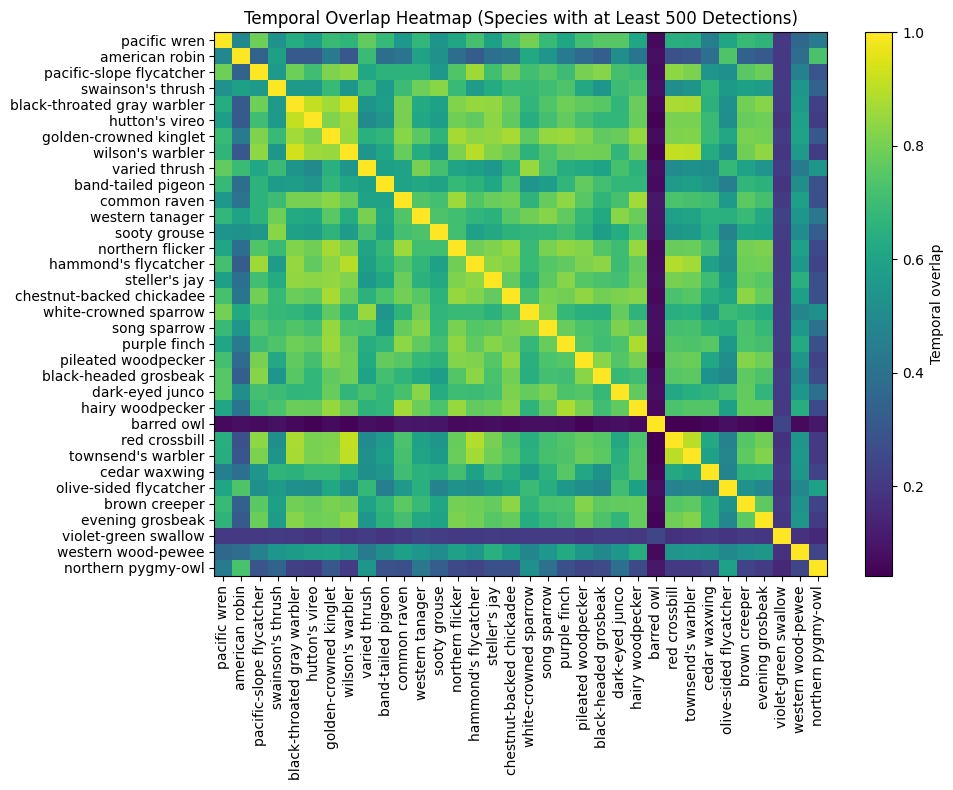

,pacific wren,american robin,pacific-slope flycatcher,swainson's thrush,black-throated gray warbler,hutton's vireo,golden-crowned kinglet,wilson's warbler,varied thrush,band-tailed pigeon,...,barred owl,red crossbill,townsend's warbler,cedar waxwing,olive-sided flycatcher,brown creeper,evening grosbeak,violet-green swallow,western wood-pewee,northern pygmy-owl
pacific wren,1.000000,0.489361,0.787322,0.526334,0.636372,0.573689,0.690224,0.668909,0.770069,0.683903,...,0.066559,0.643192,0.640370,0.454988,0.606013,0.691821,0.666280,0.200600,0.367037,0.438476
american robin,0.489361,1.000000,0.345573,0.585115,0.314762,0.314526,0.436490,0.300694,0.694119,0.386799,...,0.082100,0.279152,0.295065,0.390742,0.734741,0.338630,0.313923,0.199720,0.383522,0.723705
pacific-slope flycatcher,0.787322,0.345573,1.000000,0.562241,0.787894,0.705079,0.813128,0.838991,0.616995,0.659965,...,0.071035,0.835808,0.811041,0.541897,0.523847,0.753717,0.785726,0.202806,0.463812,0.296114
swainson's thrush,0.526334,0.585115,0.562241,1.000000,0.560413,0.561191,0.691228,0.544263,0.695172,0.567922,...,0.086019,0.515042,0.536948,0.668940,0.564036,0.587846,0.570466,0.212967,0.544843,0.347296
black-throated gray warbler,0.636372,0.314762,0.787894,0.560413,1.000000,0.911178,0.868177,0.934931,0.536920,0.577630,...,0.061167,0.878062,0.874965,0.657119,0.522639,0.797569,0.825085,0.202039,0.564861,0.223187
hutton's vireo,0.573689,0.314526,0.705079,0.561191,0.911178,1.000000,0.820383,0.859045,0.499874,0.540134,...,0.047430,0.807249,0.808274,0.691167,0.517695,0.778565,0.787664,0.190614,0.590907,0.209449
golden-crowned kinglet,0.690224,0.436490,0.813128,0.691228,0.868177,0.820383,1.000000,0.852826,0.650339,0.671211,...,0.070075,0.813226,0.816745,0.692824,0.611784,0.806065,0.799743,0.207612,0.597776,0.304157
wilson's warbler,0.668909,0.300694,0.838991,0.544263,0.934931,0.859045,0.852826,1.000000,0.543306,0.610375,...,0.050406,0.913541,0.907209,0.631057,0.523754,0.790863,0.841471,0.193624,0.555159,0.212425
varied thrush,0.770069,0.694119,0.616995,0.695172,0.536920,0.499874,0.650339,0.543306,1.000000,0.586669,...,0.082179,0.506124,0.521854,0.520359,0.680243,0.595427,0.540467,0.212610,0.440893,0.550453
band-tailed pigeon,0.683903,0.386799,0.659965,0.567922,0.577630,0.540134,0.671211,0.610375,0.586669,1.000000,...,0.069033,0.569956,0.583207,0.541820,0.452548,0.672009,0.658546,0.188061,0.513917,0.278354


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import ipywidgets as widgets
from IPython.display import display

# =========================================================
# Step 1: Prepare data
# =========================================================

df = detections.copy()

# Keep only rows with valid species names and hour values
df = df.dropna(subset=["detection_common_name", "hour"]).copy()

# Make sure hour is numeric and integer
df["hour"] = pd.to_numeric(df["hour"], errors="coerce")
df = df.dropna(subset=["hour"]).copy()
df["hour"] = df["hour"].astype(int)

# =========================================================
# Step 2: Select species with at least 500 detections
# =========================================================

species_counts = (
    df["detection_common_name"]
    .value_counts()
    .reset_index()
)

species_counts.columns = ["species", "n_detections"]

min_detections = 500

selected_species = species_counts.loc[
    species_counts["n_detections"] >= min_detections,
    "species"
].tolist()

focal_df = df[df["detection_common_name"].isin(selected_species)].copy()

# =========================================================
# Step 3: Build hourly activity table
# =========================================================

hourly_counts = (
    focal_df.groupby(["detection_common_name", "hour"])
    .size()
    .reset_index(name="detections")
)

# Add missing hours (0-23) for each species
all_hours = pd.DataFrame({"hour": range(24)})
activity_tables = []

for species in selected_species:
    species_df = hourly_counts[hourly_counts["detection_common_name"] == species].copy()
    species_df = all_hours.merge(species_df, on="hour", how="left")
    species_df["detection_common_name"] = species
    species_df["detections"] = species_df["detections"].fillna(0)
    activity_tables.append(species_df)

activity_df = pd.concat(activity_tables, ignore_index=True)

# Normalize detections within each species to create activity curves
activity_df["relative_activity"] = (
    activity_df.groupby("detection_common_name")["detections"]
    .transform(lambda x: x / x.sum() if x.sum() > 0 else 0)
)

# =========================================================
# Step 4: Calculate temporal overlap
# =========================================================

# Temporal overlap coefficient:
# overlap = sum of the minimum relative activity at each hour
species_vectors = {
    species: activity_df[activity_df["detection_common_name"] == species]
    .sort_values("hour")["relative_activity"]
    .to_numpy()
    for species in selected_species
}

overlap_results = []

for sp1, sp2 in combinations(selected_species, 2):
    overlap = np.minimum(species_vectors[sp1], species_vectors[sp2]).sum()
    overlap_results.append({
        "species_1": sp1,
        "species_2": sp2,
        "temporal_overlap": overlap
    })

overlap_df = pd.DataFrame(overlap_results).sort_values(
    by="temporal_overlap", ascending=False
)

print("Pairwise temporal overlap among selected species:")
display(overlap_df)

# Build overlap matrix
overlap_matrix = pd.DataFrame(
    index=selected_species,
    columns=selected_species,
    dtype=float
)

for species in selected_species:
    overlap_matrix.loc[species, species] = 1.0

for _, row in overlap_df.iterrows():
    sp1 = row["species_1"]
    sp2 = row["species_2"]
    overlap_matrix.loc[sp1, sp2] = row["temporal_overlap"]
    overlap_matrix.loc[sp2, sp1] = row["temporal_overlap"]

# Reorder matrix by total detections for cleaner presentation
species_order = species_counts.loc[
    species_counts["species"].isin(selected_species),
    "species"
].tolist()

overlap_matrix = overlap_matrix.loc[species_order, species_order]

# =========================================================
# Step 5: Plot temporal overlap heatmap
# =========================================================

plt.figure(figsize=(10, 8))
im = plt.imshow(overlap_matrix.values, aspect="auto")

plt.title(f"Temporal Overlap Heatmap (Species with at Least {min_detections} Detections)")
plt.xticks(range(len(overlap_matrix.columns)), overlap_matrix.columns, rotation=90)
plt.yticks(range(len(overlap_matrix.index)), overlap_matrix.index)

cbar = plt.colorbar(im)
cbar.set_label("Temporal overlap")

plt.tight_layout()
plt.show()

# Optional: show overlap matrix as a table
display(overlap_matrix)

# =========================================================
# Step 6: Function to plot selected species activity curves
# =========================================================

def plot_activity_curves(species_to_plot=None, normalize=True):
    """
    Plot hourly activity curves for a selected list of species.

    Parameters
    ----------
    species_to_plot : list or None
        List of species names to display. If None, all selected_species will be shown.
    normalize : bool
        If True, plot relative activity. If False, plot raw detections.
    """
    if species_to_plot is None:
        species_to_plot = selected_species

    plot_df = activity_df[activity_df["detection_common_name"].isin(species_to_plot)].copy()

    y_col = "relative_activity" if normalize else "detections"
    y_label = "Relative detection frequency" if normalize else "Number of detections"

    plt.figure(figsize=(12, 6))

    for species in species_to_plot:
        subset = plot_df[plot_df["detection_common_name"] == species].sort_values("hour")
        if len(subset) > 0:
            plt.plot(subset["hour"], subset[y_col], marker="o", label=species)

    plt.title("Hourly Activity Curves")
    plt.xlabel("Hour of day")
    plt.ylabel(y_label)
    plt.xticks(range(24))
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
# =========================================================
# Step 7: Interactive selector for Colab
# =========================================================

species_selector = widgets.SelectMultiple(
    options=selected_species,
    value=tuple(selected_species[:5]),
    description="Species",
    rows=min(12, len(selected_species)),
    layout=widgets.Layout(width="400px", height="250px")
)

normalize_toggle = widgets.Checkbox(
    value=True,
    description="Normalize"
)

plot_button = widgets.Button(
    description="Plot selected species",
    button_style="primary"
)

output = widgets.Output()

def on_plot_button_clicked(b):
    with output:
        output.clear_output()
        chosen_species = list(species_selector.value)
        if len(chosen_species) == 0:
            print("Please select at least one species.")
        else:
            plot_activity_curves(
                species_to_plot=chosen_species,
                normalize=normalize_toggle.value
            )

plot_button.on_click(on_plot_button_clicked)

display(widgets.VBox([
    widgets.HTML("<b>Select species to display in the activity curve plot:</b>"),
    species_selector,
    normalize_toggle,
    plot_button,
    output
]))

## Detection-Based Community Diversity

This section summarizes community-level patterns using detection-based diversity metrics. Because these metrics are calculated from acoustic detections rather than true abundance, they should be interpreted as detection-based summaries of community structure. Here, I calculate species richness, Shannon diversity, and Pielou's evenness across sites and plots.

Detection-based diversity metrics by site:


,site,richness,shannon_diversity,pielou_evenness
0,Clearwater,33,2.005745,0.573642
1,Ellsworth,51,2.251259,0.572573
2,Hoh,33,1.925422,0.550670


Detection-based diversity metrics by plot:


,site,plot,richness,shannon_diversity,pielou_evenness
0,Clearwater,92,21,1.450156,0.476317
1,Clearwater,93,27,1.889584,0.573324
2,Clearwater,96,23,1.316348,0.419822
3,Clearwater,99,23,1.641436,0.523502
4,Clearwater,103,26,1.451151,0.445398
5,Clearwater,110,26,1.463542,0.449202
6,Clearwater,115,23,2.036196,0.649402
7,Clearwater,118,24,2.020166,0.635661
8,Clearwater,122,29,1.569278,0.466035
9,Clearwater,124,26,1.708825,0.524486


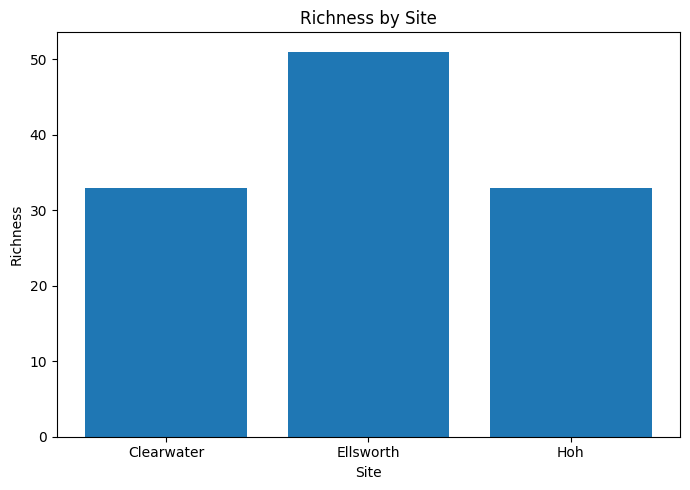

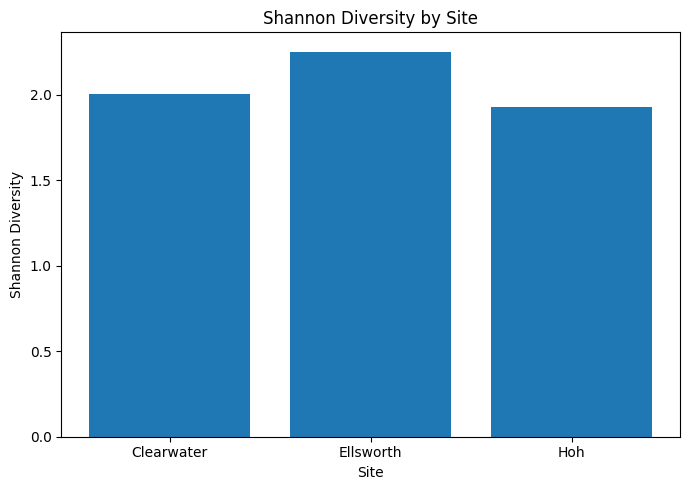

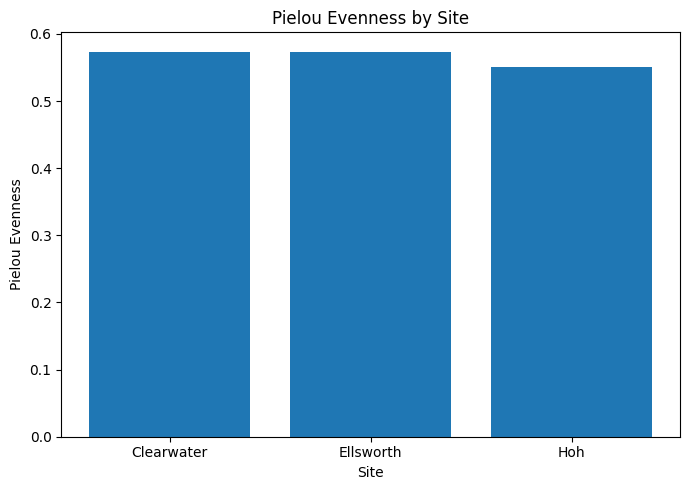

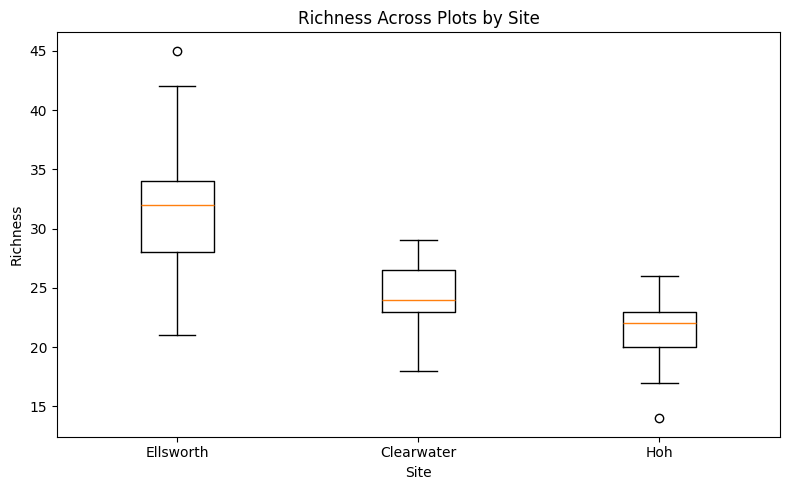

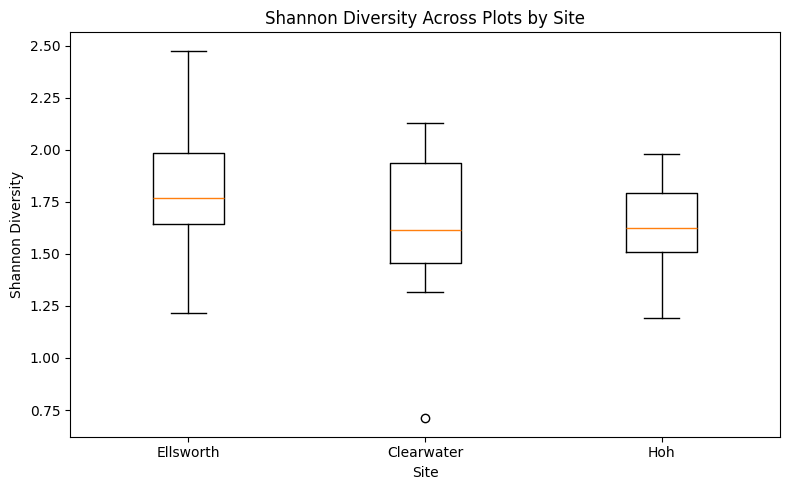

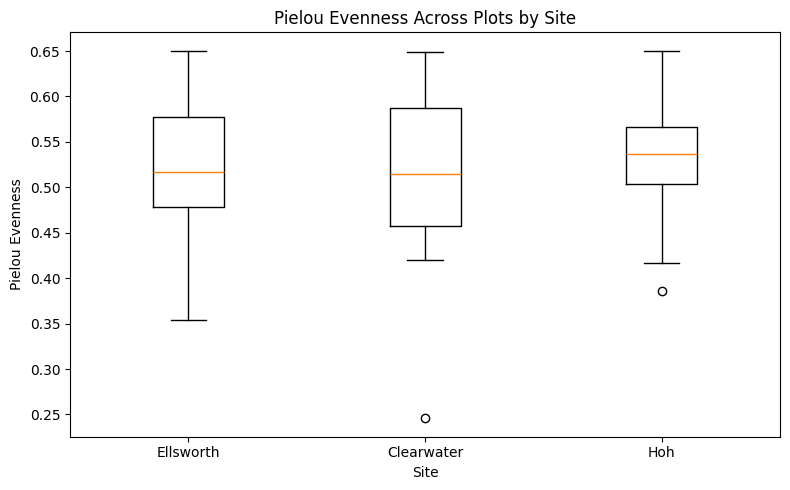

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Step 1: Prepare data
# =========================================================

df = detections.copy()

# Keep only rows with valid site, plot, and species information
df = df.dropna(subset=["site", "plot", "detection_common_name"]).copy()

# Standardize key columns
df["site"] = df["site"].astype(str).str.strip()
df["plot"] = pd.to_numeric(df["plot"], errors="coerce")
df = df.dropna(subset=["plot"]).copy()
df["plot"] = df["plot"].astype(int)

# =========================================================
# Step 2: Define diversity metric functions
# =========================================================

def shannon_diversity(counts):
    """
    Calculate Shannon diversity from a vector of species counts.
    """
    counts = np.array(counts)
    counts = counts[counts > 0]
    proportions = counts / counts.sum()
    return -np.sum(proportions * np.log(proportions))

def pielou_evenness(counts):
    """
    Calculate Pielou's evenness from a vector of species counts.
    """
    counts = np.array(counts)
    counts = counts[counts > 0]
    richness = len(counts)

    if richness <= 1:
        return np.nan

    h = shannon_diversity(counts)
    return h / np.log(richness)

# =========================================================
# Step 3: Calculate detection-based diversity by site
# =========================================================

site_species_counts = (
    df.groupby(["site", "detection_common_name"])
    .size()
    .reset_index(name="n_detections")
)

site_diversity = (
    site_species_counts.groupby("site")["n_detections"]
    .apply(list)
    .reset_index(name="count_list")
)

site_diversity["richness"] = site_diversity["count_list"].apply(lambda x: len(x))
site_diversity["shannon_diversity"] = site_diversity["count_list"].apply(shannon_diversity)
site_diversity["pielou_evenness"] = site_diversity["count_list"].apply(pielou_evenness)

site_diversity = site_diversity.drop(columns="count_list")

print("Detection-based diversity metrics by site:")
display(site_diversity)

# =========================================================
# Step 4: Calculate detection-based diversity by plot
# =========================================================

plot_species_counts = (
    df.groupby(["site", "plot", "detection_common_name"])
    .size()
    .reset_index(name="n_detections")
)

plot_diversity = (
    plot_species_counts.groupby(["site", "plot"])["n_detections"]
    .apply(list)
    .reset_index(name="count_list")
)

plot_diversity["richness"] = plot_diversity["count_list"].apply(lambda x: len(x))
plot_diversity["shannon_diversity"] = plot_diversity["count_list"].apply(shannon_diversity)
plot_diversity["pielou_evenness"] = plot_diversity["count_list"].apply(pielou_evenness)

plot_diversity = plot_diversity.drop(columns="count_list")

print("Detection-based diversity metrics by plot:")
display(plot_diversity.head(20))

# =========================================================
# Step 5: Plot diversity metrics by site
# =========================================================

metrics = ["richness", "shannon_diversity", "pielou_evenness"]

for metric in metrics:
    plt.figure(figsize=(7, 5))
    plt.bar(site_diversity["site"], site_diversity[metric])
    plt.title(f"{metric.replace('_', ' ').title()} by Site")
    plt.xlabel("Site")
    plt.ylabel(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

# =========================================================
# Step 6: Plot plot-level diversity distributions by site
# =========================================================

site_order = ["Ellsworth", "Clearwater", "Hoh"]
plot_diversity["site"] = pd.Categorical(plot_diversity["site"], categories=site_order, ordered=True)
plot_diversity = plot_diversity.sort_values("site")

for metric in metrics:
    plt.figure(figsize=(8, 5))

    data_to_plot = [
        plot_diversity.loc[plot_diversity["site"] == site, metric].dropna()
        for site in site_order
    ]

    plt.boxplot(data_to_plot, tick_labels=site_order)
    plt.title(f"{metric.replace('_', ' ').title()} Across Plots by Site")
    plt.xlabel("Site")
    plt.ylabel(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

## Species Composition Across Sites

This section compares species composition across the three study sites. The goal is to identify shared and site-specific species, and to examine which species contribute most strongly to detections within each site.

Site-by-species detection matrix:


site,Ellsworth,Clearwater,Hoh
detection_common_name,,,
american crow,33.0,0.0,0.0
american goldfinch,21.0,0.0,0.0
american robin,110402.0,121143.0,126934.0
bald eagle,54.0,0.0,0.0
band-tailed pigeon,8985.0,1655.0,1280.0
barred owl,607.0,548.0,923.0
belted kingfisher,11.0,56.0,16.0
black-headed grosbeak,2580.0,0.0,0.0
black-throated gray warbler,14709.0,15699.0,47110.0


Top 10 detected species in Ellsworth:


,species,n_detections
0,pacific wren,162467.0
1,american robin,110402.0
2,pacific-slope flycatcher,99993.0
3,swainson's thrush,92275.0
4,hutton's vireo,37544.0
5,wilson's warbler,19985.0
6,varied thrush,15847.0
7,black-throated gray warbler,14709.0
8,golden-crowned kinglet,13634.0
9,sooty grouse,9061.0


Top 10 detected species in Clearwater:


,species,n_detections
0,pacific wren,124479.0
1,american robin,121143.0
2,swainson's thrush,74736.0
3,pacific-slope flycatcher,70770.0
4,golden-crowned kinglet,22894.0
5,black-throated gray warbler,15699.0
6,hutton's vireo,11717.0
7,varied thrush,6820.0
8,wilson's warbler,6262.0
9,western tanager,5694.0


Top 10 detected species in Hoh:


,species,n_detections
0,pacific wren,146409.0
1,american robin,126934.0
2,pacific-slope flycatcher,84247.0
3,swainson's thrush,78122.0
4,black-throated gray warbler,47110.0
5,golden-crowned kinglet,13878.0
6,hutton's vireo,8973.0
7,varied thrush,7109.0
8,hammond's flycatcher,4292.0
9,wilson's warbler,3807.0


Number of species present in all 3 sites: 33
Shared species:
['american robin', 'band-tailed pigeon', 'barred owl', 'belted kingfisher', 'black-throated gray warbler', 'common raven', 'dark-eyed junco', 'golden-crowned kinglet', 'hairy woodpecker', "hammond's flycatcher", "hutton's vireo", 'marbled murrelet', 'northern flicker', 'northern pygmy-owl', 'olive-sided flycatcher', 'pacific wren', 'pacific-slope flycatcher', 'pileated woodpecker', 'purple finch', 'red crossbill', 'red-breasted nuthatch', 'rufous hummingbird', 'song sparrow', 'sooty grouse', 'spotted towhee', "swainson's thrush", "townsend's warbler", 'varied thrush', 'violet-green swallow', 'western screech-owl', 'western tanager', 'western wood-pewee', "wilson's warbler"]

Number of species unique to Ellsworth: 18
['american crow', 'american goldfinch', 'bald eagle', 'black-headed grosbeak', 'brown creeper', 'canada jay', 'cedar waxwing', 'chestnut-backed chickadee', 'evening grosbeak', 'orange-crowned warbler', 'pine siski

site,Ellsworth,Clearwater,Hoh
detection_common_name,,,
american crow,0.000053,0.000000,0.000000
american goldfinch,0.000033,0.000000,0.000000
american robin,0.175930,0.252940,0.237856
bald eagle,0.000086,0.000000,0.000000
band-tailed pigeon,0.014318,0.003456,0.002399
barred owl,0.000967,0.001144,0.001730
belted kingfisher,0.000018,0.000117,0.000030
black-headed grosbeak,0.004111,0.000000,0.000000
black-throated gray warbler,0.023439,0.032779,0.088277


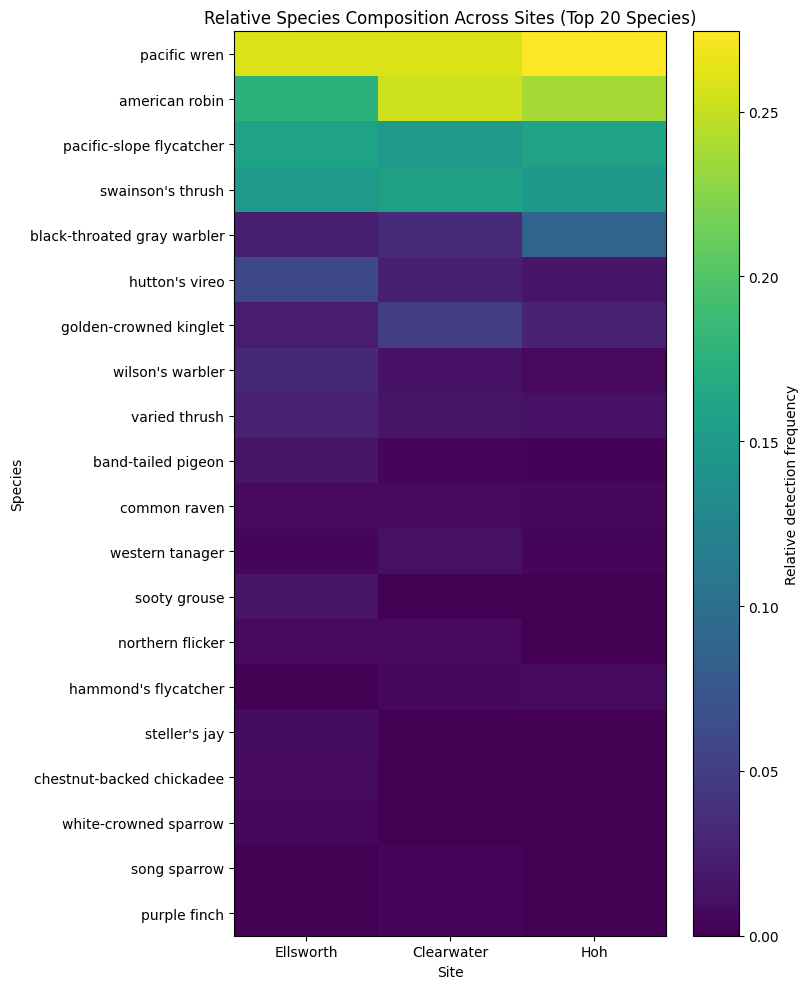

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Step 1: Prepare data
# =========================================================

df = detections.copy()

# Keep only rows with valid site and species information
df = df.dropna(subset=["site", "detection_common_name"]).copy()
df["site"] = df["site"].astype(str).str.strip()

site_order = ["Ellsworth", "Clearwater", "Hoh"]

# =========================================================
# Step 2: Build site-by-species detection matrix
# =========================================================

site_species_counts = (
    df.groupby(["detection_common_name", "site"])
    .size()
    .reset_index(name="n_detections")
)

site_species_matrix = (
    site_species_counts.pivot(
        index="detection_common_name",
        columns="site",
        values="n_detections"
    )
    .fillna(0)
)

# Keep a consistent site order if all are present
existing_sites = [s for s in site_order if s in site_species_matrix.columns]
site_species_matrix = site_species_matrix.reindex(columns=existing_sites)

print("Site-by-species detection matrix:")
display(site_species_matrix.head(20))

# =========================================================
# Step 3: Top detected species within each site
# =========================================================

top_n = 10

for site in existing_sites:
    top_species_site = (
        site_species_matrix[site]
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    top_species_site.columns = ["species", "n_detections"]

    print(f"Top {top_n} detected species in {site}:")
    display(top_species_site)

# =========================================================
# Step 4: Shared and site-specific species
# =========================================================

presence_absence = (site_species_matrix > 0).astype(int)
presence_absence["n_sites_present"] = presence_absence.sum(axis=1)

# Species present in all three sites
shared_species = presence_absence[presence_absence["n_sites_present"] == len(existing_sites)].index.tolist()

print(f"Number of species present in all {len(existing_sites)} sites: {len(shared_species)}")
print("Shared species:")
print(shared_species)

# Species unique to each site
for site in existing_sites:
    unique_species = presence_absence[
        (presence_absence[site] == 1) & (presence_absence["n_sites_present"] == 1)
    ].index.tolist()

    print(f"\nNumber of species unique to {site}: {len(unique_species)}")
    print(unique_species)

# =========================================================
# Step 5: Relative composition by site
# =========================================================

site_species_relative = site_species_matrix.div(site_species_matrix.sum(axis=0), axis=1)

print("Relative detection frequency by site:")
display(site_species_relative.head(20))

# =========================================================
# Step 6: Heatmap of the most common species
# =========================================================

# Select top 20 species by total detections across all sites
top_species_overall = (
    site_species_matrix.sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap_df = site_species_relative.loc[top_species_overall, existing_sites]

plt.figure(figsize=(8, 10))
im = plt.imshow(heatmap_df.values, aspect="auto")

plt.title("Relative Species Composition Across Sites (Top 20 Species)")
plt.xlabel("Site")
plt.ylabel("Species")
plt.xticks(range(len(existing_sites)), existing_sites)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

cbar = plt.colorbar(im)
cbar.set_label("Relative detection frequency")

plt.tight_layout()
plt.show()

## Habitat-Related Analysis Using the Matched Subset Only

This section focuses on habitat-related questions using only the subset of detections that could be matched to plot- and ARU-level metadata. Here, I examine whether bird detections and community composition vary across dominant ecosystem types and whether species detections show associations with dominant tree species and understory plant labels.

These analyses are exploratory and descriptive. They are based on categorical habitat labels rather than continuous environmental measurements. Other habitat-related variables, such as distance to roads, riparian proximity, disturbance intensity, or standardized habitat description data, are not currently available in a complete and consistent form, so they are not included in this notebook.

Matched subset shape: (875106, 35)
Number of matched detections: 875106
Unique ecosystem types:
Dominant Ecosystem Type
Forest_Open     453332
Forest_Dense    325140
Wetland          62486
Clear_cut        34148
Name: count, dtype: int64
Detection-based diversity by dominant ecosystem type:


,Dominant Ecosystem Type,richness,shannon_diversity,pielou_evenness
0,Clear_cut,44,2.008549,0.530774
1,Forest_Dense,42,2.031054,0.543401
2,Forest_Open,48,1.924270,0.497073
3,Wetland,28,1.798263,0.539662


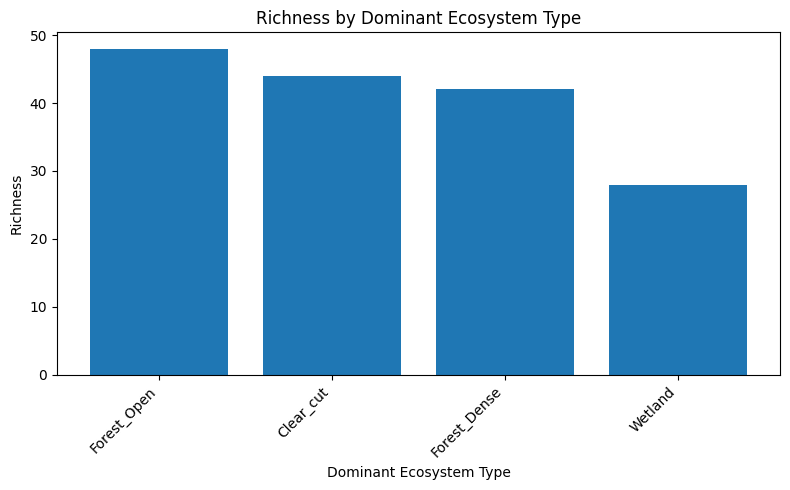

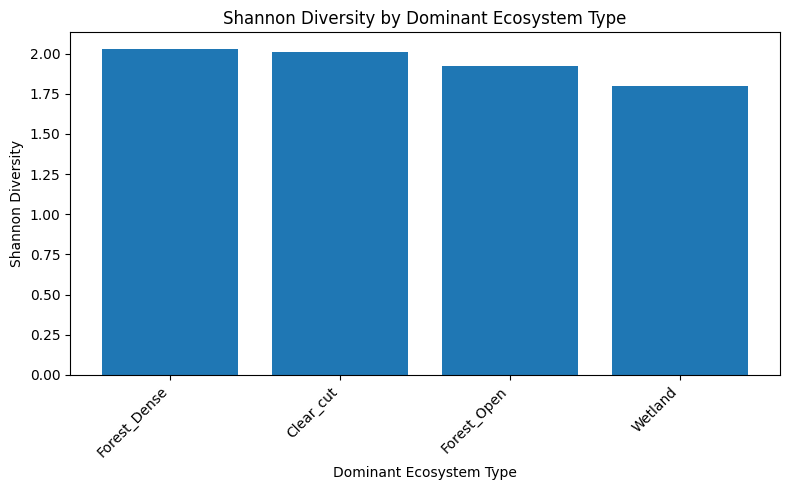

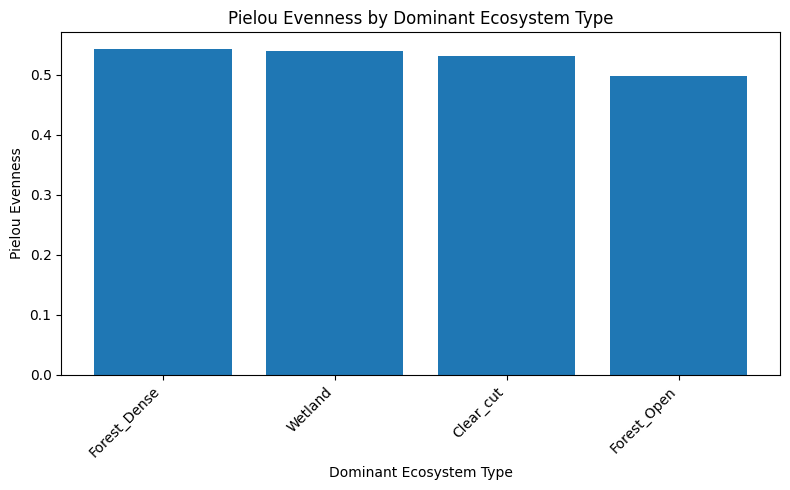

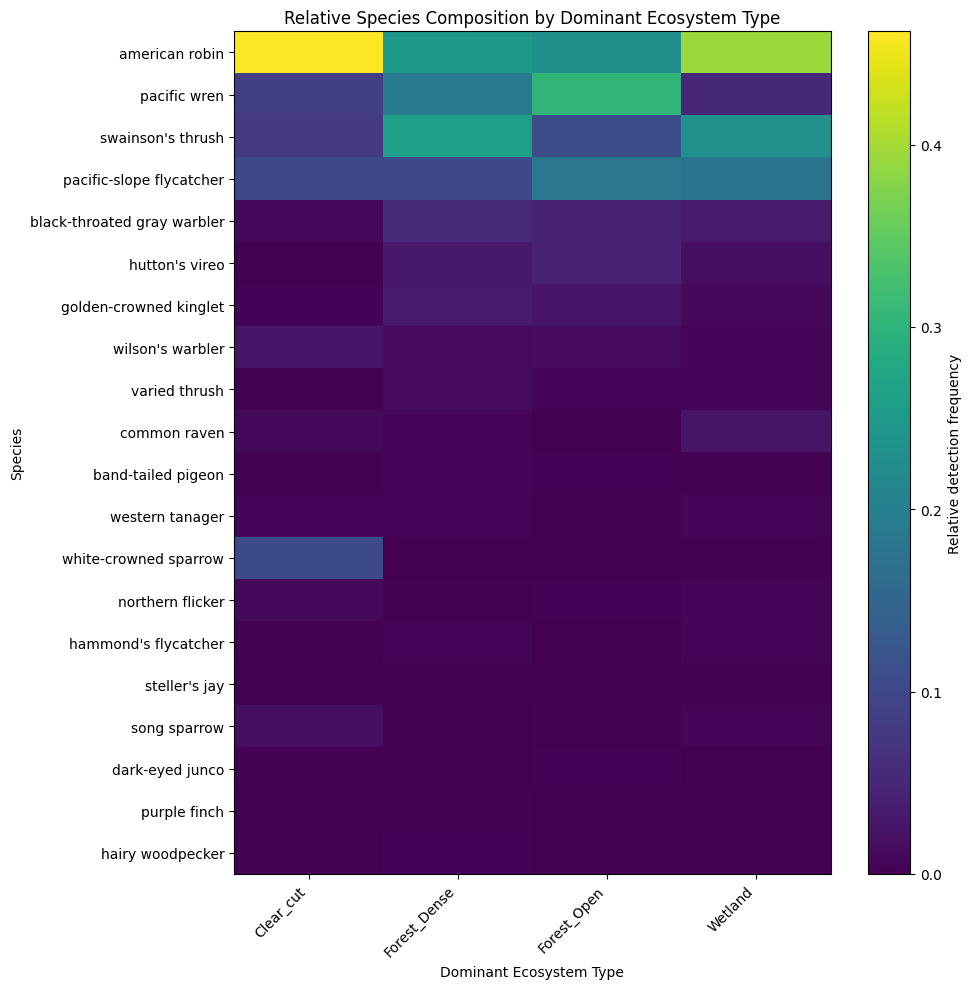

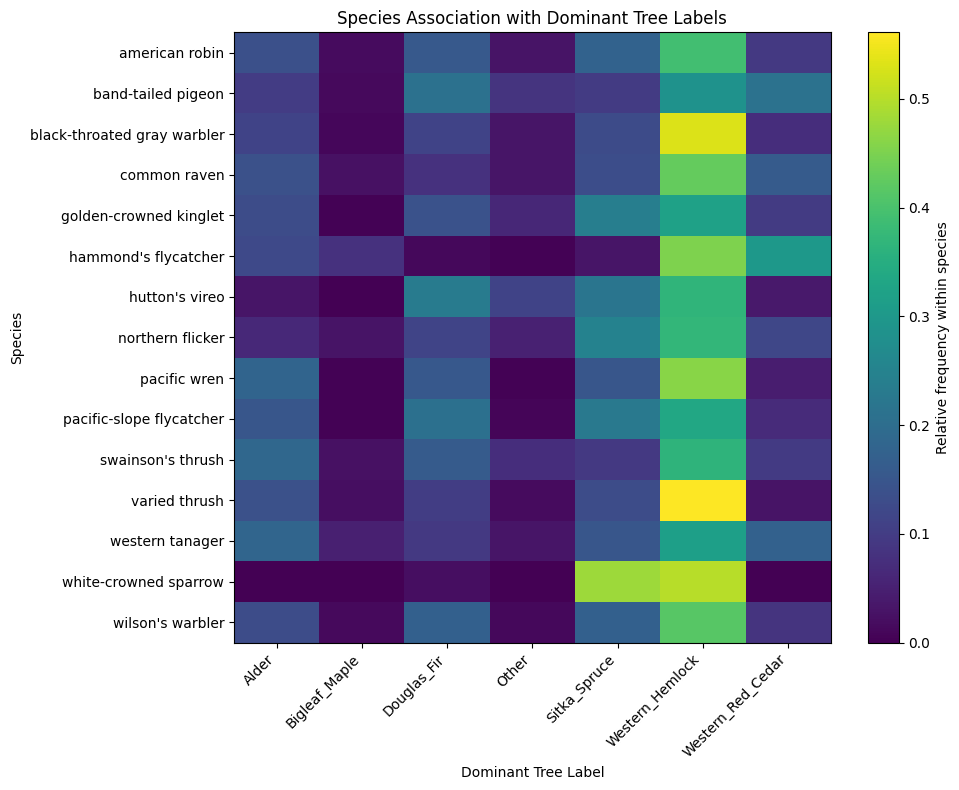

tree_label,Alder,Bigleaf_Maple,Douglas_Fir,Other,Sitka_Spruce,Western_Hemlock,Western_Red_Cedar
detection_common_name,,,,,,,
american robin,0.136162,0.017237,0.157269,0.029043,0.175660,0.392123,0.092506
band-tailed pigeon,0.099251,0.013343,0.208971,0.083752,0.097301,0.285949,0.211434
black-throated gray warbler,0.112384,0.008804,0.112836,0.031391,0.128767,0.531785,0.074034
common raven,0.138147,0.026246,0.079780,0.031647,0.132935,0.429411,0.161834
golden-crowned kinglet,0.131488,0.003133,0.142241,0.062233,0.240491,0.321987,0.098427
hammond's flycatcher,0.123016,0.079365,0.011905,0.003968,0.030952,0.451984,0.298810
hutton's vireo,0.030717,0.000048,0.233835,0.112325,0.217734,0.367980,0.037362
northern flicker,0.064752,0.030182,0.114612,0.052387,0.247706,0.370695,0.119665
pacific wren,0.181653,0.003974,0.154250,0.002667,0.151092,0.461831,0.044533


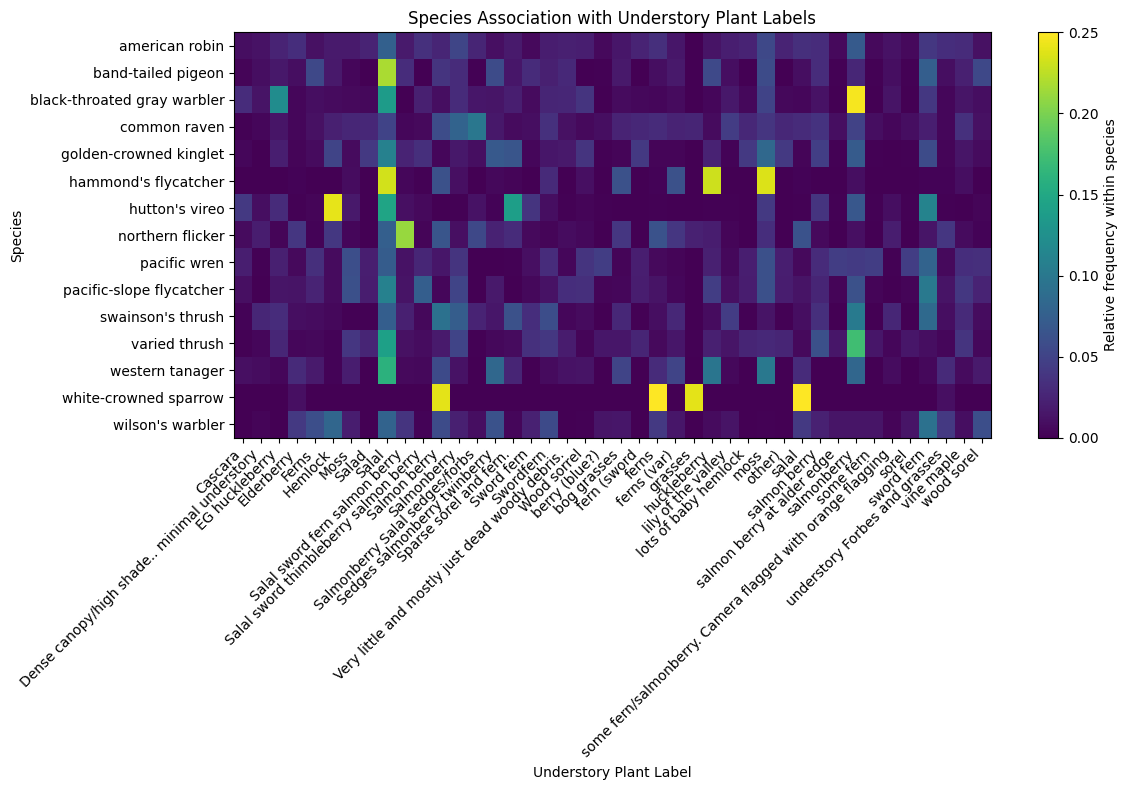

understory_label,Cascara,Dense canopy/high shade.. minimal understory,EG huckleberry,Elderberry,Ferns,Hemlock,Moss,Salad,Salal,Salal sword fern salmon berry,...,salmon berry,salmon berry at alder edge,salmonberry,some fern,some fern/salmonberry. Camera flagged with orange flagging,sorel,sword fern,understory Forbes and grasses,vine maple,wood sorel
detection_common_name,,,,,,,,,,,,,,,,,,,,,
american robin,0.009379,0.012059,0.024757,0.032823,0.011259,0.017833,0.018062,0.024939,0.076666,0.017829,...,0.031582,0.006356,0.070479,0.006356,0.012059,0.006356,0.040447,0.032823,0.030695,0.011259
band-tailed pigeon,0.003150,0.009583,0.016015,0.008795,0.054476,0.017459,0.003938,0.000525,0.218430,0.032029,...,0.031636,0.001706,0.026516,0.001706,0.009583,0.001706,0.075085,0.008795,0.021790,0.054476
black-throated gray warbler,0.032181,0.013242,0.121639,0.004671,0.009503,0.007168,0.006709,0.005629,0.137540,0.000729,...,0.012608,0.000148,0.246598,0.000148,0.013242,0.000148,0.040416,0.004671,0.014498,0.009503
common raven,0.001003,0.004013,0.013862,0.004651,0.010762,0.022070,0.026813,0.027725,0.050433,0.004378,...,0.036753,0.009485,0.048974,0.009485,0.004013,0.009485,0.020520,0.004651,0.034929,0.010762
golden-crowned kinglet,0.004045,0.000497,0.021268,0.002934,0.007192,0.050816,0.006884,0.041684,0.109558,0.025266,...,0.046440,0.001845,0.071942,0.001845,0.000497,0.001845,0.057062,0.002934,0.014407,0.007192
hammond's flycatcher,0.000000,0.000000,0.000311,0.002639,0.000776,0.000311,0.008539,0.000466,0.233349,0.004037,...,0.000776,0.000621,0.008850,0.000621,0.000000,0.000621,0.002484,0.002639,0.009626,0.000776
hutton's vireo,0.041316,0.009487,0.030597,0.001321,0.003808,0.240546,0.016817,0.000022,0.145851,0.010654,...,0.037993,0.001453,0.067709,0.001453,0.009487,0.001453,0.112085,0.001321,0.000044,0.003808
northern flicker,0.007400,0.019732,0.002995,0.039112,0.002643,0.040169,0.004405,0.000000,0.075229,0.211416,...,0.006695,0.000529,0.010571,0.000529,0.019732,0.000529,0.013918,0.039112,0.006871,0.002643
pacific wren,0.021193,0.001084,0.021533,0.006035,0.033486,0.007363,0.059581,0.020607,0.073146,0.011731,...,0.031218,0.045609,0.042851,0.045609,0.001084,0.045609,0.079158,0.006035,0.032647,0.033486


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Step 1: Rebuild the matched subset
# =========================================================

# Copy original datasets
det = detections.copy()
meta = metadata_df.copy()

# Keep only columns needed for habitat-related analyses
meta_clean = meta[[
    "Property",
    "Plot ID",
    "ARU Number",
    "Dominant Ecosystem Type",
    "Dominant Tree Species",
    "Dominant Understory Plant(s)"
]].copy()

# Standardize merge keys in detections
det["site_std"] = det["site"].astype(str).str.strip().str.lower()
det["plot_std"] = pd.to_numeric(det["plot"], errors="coerce")
det["aru_std"] = pd.to_numeric(det["aru"], errors="coerce")

# Standardize merge keys in metadata
meta_clean["site_std"] = meta_clean["Property"].astype(str).str.strip().str.lower()
meta_clean["plot_std"] = pd.to_numeric(meta_clean["Plot ID"], errors="coerce")
meta_clean["aru_std"] = pd.to_numeric(meta_clean["ARU Number"], errors="coerce")

# Merge
matched_df = det.merge(
    meta_clean,
    on=["site_std", "plot_std", "aru_std"],
    how="left"
)

# Keep only matched rows for habitat-related analyses
matched_df = matched_df[
    matched_df["Dominant Ecosystem Type"].notna()
].copy()

print("Matched subset shape:", matched_df.shape)
print("Number of matched detections:", len(matched_df))
print("Unique ecosystem types:")
print(matched_df["Dominant Ecosystem Type"].value_counts())

# =========================================================
# Step 2: Diversity by dominant ecosystem type
# =========================================================

def shannon_diversity(counts):
    counts = np.array(counts)
    counts = counts[counts > 0]
    proportions = counts / counts.sum()
    return -np.sum(proportions * np.log(proportions))

def pielou_evenness(counts):
    counts = np.array(counts)
    counts = counts[counts > 0]
    richness = len(counts)
    if richness <= 1:
        return np.nan
    return shannon_diversity(counts) / np.log(richness)

ecosystem_species_counts = (
    matched_df.groupby(["Dominant Ecosystem Type", "detection_common_name"])
    .size()
    .reset_index(name="n_detections")
)

ecosystem_diversity = (
    ecosystem_species_counts.groupby("Dominant Ecosystem Type")["n_detections"]
    .apply(list)
    .reset_index(name="count_list")
)

ecosystem_diversity["richness"] = ecosystem_diversity["count_list"].apply(len)
ecosystem_diversity["shannon_diversity"] = ecosystem_diversity["count_list"].apply(shannon_diversity)
ecosystem_diversity["pielou_evenness"] = ecosystem_diversity["count_list"].apply(pielou_evenness)
ecosystem_diversity = ecosystem_diversity.drop(columns="count_list")

print("Detection-based diversity by dominant ecosystem type:")
display(ecosystem_diversity)

# Plot diversity metrics by ecosystem type
metrics = ["richness", "shannon_diversity", "pielou_evenness"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plot_df = ecosystem_diversity.sort_values(metric, ascending=False)
    plt.bar(plot_df["Dominant Ecosystem Type"], plot_df[metric])
    plt.title(f"{metric.replace('_', ' ').title()} by Dominant Ecosystem Type")
    plt.xlabel("Dominant Ecosystem Type")
    plt.ylabel(metric.replace("_", " ").title())
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# =========================================================
# Step 3: Species composition across ecosystem types
# =========================================================

ecosystem_species_matrix = (
    ecosystem_species_counts.pivot(
        index="detection_common_name",
        columns="Dominant Ecosystem Type",
        values="n_detections"
    )
    .fillna(0)
)

# Convert to relative composition within each ecosystem type
ecosystem_species_relative = ecosystem_species_matrix.div(
    ecosystem_species_matrix.sum(axis=0),
    axis=1
)

# Select top 20 species overall in the matched subset
top_species_matched = (
    matched_df["detection_common_name"]
    .value_counts()
    .head(20)
    .index
)

heatmap_df = ecosystem_species_relative.loc[
    ecosystem_species_relative.index.intersection(top_species_matched)
]

# Reorder rows by total detections in matched subset
species_order = (
    matched_df["detection_common_name"]
    .value_counts()
    .loc[lambda x: x.index.isin(heatmap_df.index)]
    .index
)
heatmap_df = heatmap_df.loc[species_order]

plt.figure(figsize=(10, 10))
im = plt.imshow(heatmap_df.values, aspect="auto")
plt.title("Relative Species Composition by Dominant Ecosystem Type")
plt.xlabel("Dominant Ecosystem Type")
plt.ylabel("Species")
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
cbar = plt.colorbar(im)
cbar.set_label("Relative detection frequency")
plt.tight_layout()
plt.show()

# =========================================================
# Step 4: Tree-species association (exploratory)
# =========================================================

# Keep rows with non-missing tree labels
tree_df = matched_df[
    matched_df["Dominant Tree Species"].notna() &
    matched_df["detection_common_name"].notna()
].copy()

# Split comma-separated tree labels
tree_df["tree_label"] = tree_df["Dominant Tree Species"].astype(str).str.split(",")

# Explode to one tree label per row
tree_df = tree_df.explode("tree_label")
tree_df["tree_label"] = tree_df["tree_label"].astype(str).str.strip()

# Remove empty labels
tree_df = tree_df[tree_df["tree_label"] != ""].copy()

# Keep only common tree labels with enough detections
tree_label_counts = tree_df["tree_label"].value_counts()
common_tree_labels = tree_label_counts[tree_label_counts >= 200].index.tolist()

tree_df = tree_df[tree_df["tree_label"].isin(common_tree_labels)].copy()

# Select top 15 species in the matched subset
top_species_for_plant = (
    matched_df["detection_common_name"]
    .value_counts()
    .head(15)
    .index
)

tree_species_counts = (
    tree_df[tree_df["detection_common_name"].isin(top_species_for_plant)]
    .groupby(["detection_common_name", "tree_label"])
    .size()
    .reset_index(name="n_detections")
)

tree_species_matrix = (
    tree_species_counts.pivot(
        index="detection_common_name",
        columns="tree_label",
        values="n_detections"
    )
    .fillna(0)
)

# Normalize within each species to show where each species is most often detected
tree_species_relative = tree_species_matrix.div(
    tree_species_matrix.sum(axis=1),
    axis=0
)

plt.figure(figsize=(10, 8))
im = plt.imshow(tree_species_relative.values, aspect="auto")
plt.title("Species Association with Dominant Tree Labels")
plt.xlabel("Dominant Tree Label")
plt.ylabel("Species")
plt.xticks(range(len(tree_species_relative.columns)), tree_species_relative.columns, rotation=45, ha="right")
plt.yticks(range(len(tree_species_relative.index)), tree_species_relative.index)
cbar = plt.colorbar(im)
cbar.set_label("Relative frequency within species")
plt.tight_layout()
plt.show()

display(tree_species_relative)

# =========================================================
# Step 5: Understory-species association (exploratory)
# =========================================================

under_df = matched_df[
    matched_df["Dominant Understory Plant(s)"].notna() &
    matched_df["detection_common_name"].notna()
].copy()

# Split comma-separated understory labels
under_df["understory_label"] = under_df["Dominant Understory Plant(s)"].astype(str).str.split(",")

# Explode to one label per row
under_df = under_df.explode("understory_label")
under_df["understory_label"] = under_df["understory_label"].astype(str).str.strip()

# Remove empty labels
under_df = under_df[under_df["understory_label"] != ""].copy()

# Keep only common understory labels with enough detections
under_label_counts = under_df["understory_label"].value_counts()
common_under_labels = under_label_counts[under_label_counts >= 200].index.tolist()

under_df = under_df[under_df["understory_label"].isin(common_under_labels)].copy()

under_species_counts = (
    under_df[under_df["detection_common_name"].isin(top_species_for_plant)]
    .groupby(["detection_common_name", "understory_label"])
    .size()
    .reset_index(name="n_detections")
)

under_species_matrix = (
    under_species_counts.pivot(
        index="detection_common_name",
        columns="understory_label",
        values="n_detections"
    )
    .fillna(0)
)

# Normalize within each species
under_species_relative = under_species_matrix.div(
    under_species_matrix.sum(axis=1),
    axis=0
)

plt.figure(figsize=(12, 8))
im = plt.imshow(under_species_relative.values, aspect="auto")
plt.title("Species Association with Understory Plant Labels")
plt.xlabel("Understory Plant Label")
plt.ylabel("Species")
plt.xticks(range(len(under_species_relative.columns)), under_species_relative.columns, rotation=45, ha="right")
plt.yticks(range(len(under_species_relative.index)), under_species_relative.index)
cbar = plt.colorbar(im)
cbar.set_label("Relative frequency within species")
plt.tight_layout()
plt.show()

display(under_species_relative)